# Pertemuan 10 - Algoritma Klasifikasi (Bagian 2): Random Forest & Imbalanced Dataset

**Nama:** Moch Faris Oldie  
**NIM:** 250401020048  
**Kelas:** IF401

**Tujuan:** mempelajari ensemble learning (Random Forest), menangani dataset tidak seimbang melalui class_weight dan SMOTE, serta memprediksi Customer Churn dengan metrik yang tepat (precision, recall, F1, ROC-AUC).

## 1. Dataset & Eksplorasi

Karena dataset Telco Customer Churn (Kaggle) tidak disertakan sebagai berkas lokal, dibuat dataset sintetis yang meniru distribusi dan pola churn-nya (±26% churn, tergolong imbalanced) agar notebook tetap dapat dijalankan mandiri dari awal sampai akhir.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 7043

tenure = np.clip(np.random.gamma(2.0, 10.0, n), 0, 72).round(0)
monthly = np.clip(np.random.normal(65, 28, n), 20, 120).round(2)

df = pd.DataFrame({
    'tenure': tenure,
    'MonthlyCharges': monthly,
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n,
                                  p=[0.55, 0.24, 0.21]),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n,
                                         p=[0.30, 0.45, 0.25]),
    'OnlineSecurity': np.random.choice(['Yes', 'No', 'No internet service'], n,
                                        p=[0.45, 0.40, 0.15]),
    'TechSupport': np.random.choice(['Yes', 'No', 'No internet service'], n,
                                     p=[0.40, 0.45, 0.15]),
    'PaymentMethod': np.random.choice(
        ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'],
        n, p=[0.34, 0.20, 0.24, 0.22]),
})

# Probabilitas churn dibangun dari pola yang realistis
z = (-3.4 - 0.045 * df['tenure'] + 0.02 * df['MonthlyCharges']
     + 1.4 * (df['Contract'] == 'Month-to-month')
     - 1.2 * (df['Contract'] == 'Two year')
     + 0.8 * (df['InternetService'] == 'Fiber optic')
     + 0.7 * (df['PaymentMethod'] == 'Electronic check')
     + 0.5 * (df['OnlineSecurity'] == 'No')
     + 0.5 * (df['TechSupport'] == 'No'))
p_churn = 1 / (1 + np.exp(-z))
df['Churn'] = np.where(np.random.rand(n) < p_churn, 'Yes', 'No')

print('Shape:', df.shape)
print('Distribusi target Churn:')
print(df['Churn'].value_counts(normalize=True).round(3))

Shape: (7043, 8)
Distribusi target Churn:
Churn
No     0.74
Yes    0.26
Name: proportion, dtype: float64


Terlihat proporsi churn sekitar **26%**, sehingga dataset bersifat **imbalanced**. Model yang selalu memprediksi 'Tidak Churn' akan mendapat akurasi ±74% tanpa mendeteksi satu pun pelanggan berisiko. Inilah yang disebut **Accuracy Paradox**: accuracy tinggi bisa menyesatkan.

## 2. Preprocessing

Lakukan one-hot encoding pada fitur kategorikal, lalu bagi data latih/uji secara stratified.

In [2]:
from sklearn.model_selection import train_test_split

df_model = df.copy()
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

X = pd.get_dummies(df_model.drop('Churn', axis=1), drop_first=True)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Fitur:', X.shape[1])
print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])

Fitur: 13
Train: 5634 | Test: 1409


## 3. Latih Tiga Skenario Model

Bandingkan tiga skenario penanganan imbalance: (1) tanpa penanganan, (2) dengan `class_weight='balanced'`, dan (3) dengan SMOTE (diterapkan **hanya pada data latih**).

In [3]:
from sklearn.ensemble import RandomForestClassifier

# Skenario 1: tanpa penanganan imbalance
rf_base = RandomForestClassifier(n_estimators=200, random_state=42)
rf_base.fit(X_train, y_train)

# Skenario 2: class_weight balanced
rf_bal = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_bal.fit(X_train, y_train)

print('Skenario 1 & 2 selesai dilatih.')

Skenario 1 & 2 selesai dilatih.


In [4]:
from imblearn.over_sampling import SMOTE

# Skenario 3: SMOTE (hanya pada data latih)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(n_estimators=200, random_state=42)
rf_smote.fit(X_res, y_res)

print('Sebelum SMOTE:', pd.Series(y_train).value_counts().to_dict())
print('Setelah SMOTE:', pd.Series(y_res).value_counts().to_dict())

Sebelum SMOTE: {0: 4171, 1: 1463}
Setelah SMOTE: {0: 4171, 1: 4171}


## 4. Evaluasi: Confusion Matrix & Metrik

Fokus evaluasi pada **kelas churn (kelas 1)**. Tampilkan classification report dan ROC-AUC untuk setiap skenario.

In [5]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

skenario = [('Tanpa penanganan', rf_base),
            ('class_weight=balanced', rf_bal),
            ('SMOTE', rf_smote)]

for nama, model in skenario:
    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f'=== Skenario: {nama} ===')
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f'ROC-AUC (kelas churn): {roc_auc_score(y_test, proba):.3f}\n')

=== Skenario: Tanpa penanganan ===
Confusion Matrix:


[[925 118]
 [251 115]]
              precision    recall  f1-score   support

           0       0.79      0.89      0.83      1043
           1       0.49      0.31      0.38       366

    accuracy                           0.74      1409
   macro avg       0.64      0.60      0.61      1409
weighted avg       0.71      0.74      0.72      1409

ROC-AUC (kelas churn): 0.732

=== Skenario: class_weight=balanced ===
Confusion Matrix:
[[822 221]
 [182 184]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.80      1043
           1       0.45      0.50      0.48       366

    accuracy                           0.71      1409
   macro avg       0.64      0.65      0.64      1409
weighted avg       0.72      0.71      0.72      1409

ROC-AUC (kelas churn): 0.733



=== Skenario: SMOTE ===
Confusion Matrix:
[[850 193]
 [206 160]]
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1043
           1       0.45      0.44      0.45       366

    accuracy                           0.72      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.72      0.72      1409

ROC-AUC (kelas churn): 0.717



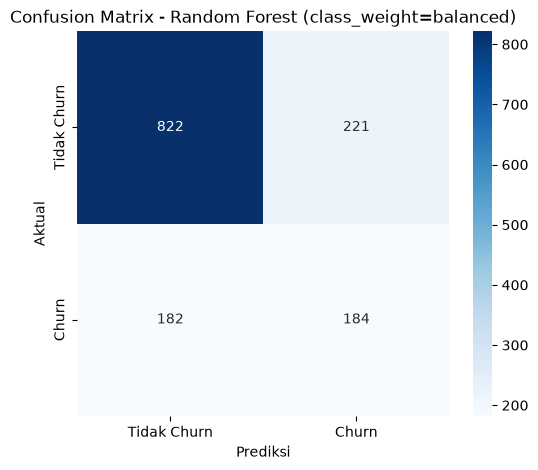

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_bal = rf_bal.predict(X_test)
cm = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest (class_weight=balanced)')
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.show()

## Interpretasi Metrik

Pada dataset churn yang imbalanced, **Accuracy saja menyesatkan**. Model tanpa penanganan cenderung menebak kelas mayoritas sehingga recall kelas churn rendah. Setelah menggunakan `class_weight='balanced'` atau SMOTE, **Recall** kelas churn meningkat, artinya lebih banyak pelanggan berisiko yang berhasil terdeteksi. Karena tujuan bisnis adalah tidak melewatkan pelanggan yang akan pergi, **Recall (bersama F1 dan PR/ROC-AUC) lebih relevan daripada Accuracy**. Accuracy tinggi pada data tidak seimbang bisa dicapai hanya dengan memprediksi semua data sebagai kelas mayoritas tanpa mendeteksi pelanggan churn sama sekali.

## 5. Probabilitas Churn & Feature Importance

Gunakan `predict_proba` untuk melihat pelanggan dengan risiko churn tertinggi, serta fitur paling berpengaruh terhadap prediksi.

In [7]:
proba_churn = rf_bal.predict_proba(X_test)[:, 1]

hasil = X_test.copy()
hasil['prob_churn'] = proba_churn
hasil['churn_aktual'] = y_test.values

print('10 pelanggan dengan risiko churn tertinggi:')
print(hasil.nlargest(10, 'prob_churn')[['prob_churn', 'churn_aktual']].round(3))

10 pelanggan dengan risiko churn tertinggi:
      prob_churn  churn_aktual
4657       0.995             1
6576       0.980             0
5718       0.980             1
6793       0.980             1
881        0.980             1
4136       0.970             0
4988       0.970             0
6269       0.965             1
6096       0.960             0
2138       0.955             0


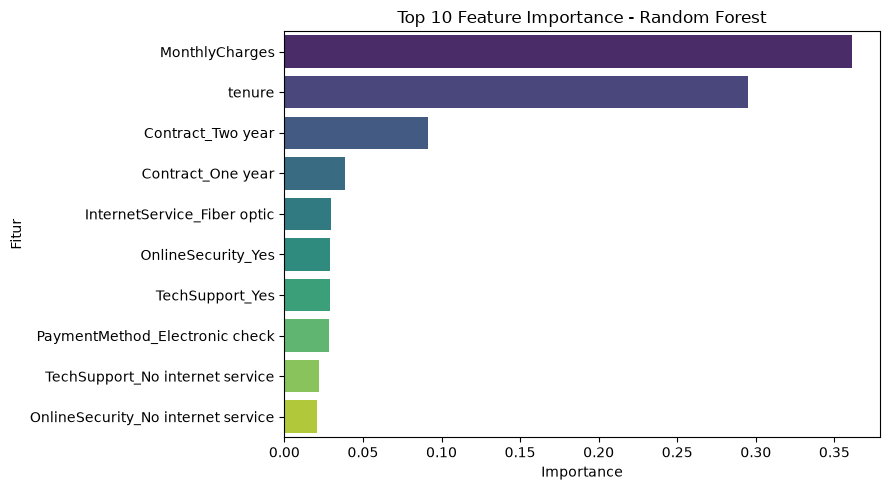

In [8]:
imp = pd.DataFrame({'Fitur': X.columns, 'Importance': rf_bal.feature_importances_})
imp = imp.sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=imp.head(10), x='Importance', y='Fitur',
            hue='Fitur', palette='viridis', legend=False)
plt.title('Top 10 Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

## Kesimpulan

Pada pertemuan ini saya mempelajari ensemble learning khususnya **Random Forest** yang menggabungkan banyak decision tree melalui bootstrap sampling dan random feature selection, serta menangani **imbalanced dataset** dengan tiga pendekatan: tanpa penanganan, `class_weight='balanced'`, dan SMOTE. Temuan utama: pada data churn yang tidak seimbang, accuracy dapat menyesatkan (accuracy paradox), sehingga metrik yang lebih relevan adalah recall, precision, F1-score, dan ROC-AUC untuk kelas minoritas; class_weight dan SMOTE terbukti meningkatkan recall kelas churn. Keterbatasan praktik ini adalah dataset churn dibuat sintetis (meniru Telco) sehingga belum mewakili data operasional asli, dan tuning threshold belum dieksplorasi lebih lanjut.